# Assignment 1: Data Parsing, Cleansing and Integration
## Tasks 1 and 2
#### Student Name: Prathibha Magesh
#### Student ID: s3859590


Environment: Python 3 and Jupyter notebook

Libraries used:
* pandas
* re
* numpy

## Introductionn
This hisessmentment involved working with two datasets: one provided in XML format and the other in CSV. 

The main objectives were to:
- Parse structured data from the XML file into a usable format.
- Audit the parsed data to identify issues such as typos, missing values, invalid entries, and outliers.
- Cleanse the data by correcting errors, applying logical rules, and ensuring consistency.
- Maintain a detailed error log documenting all detected issues and corrections.
- Integrate the cleaned XML dataset with the provided CSV dataset, resolving schema and data conflicts.

During the process, common problems such as typographical errors in categorical fields, invalid numeric values (e.g., negative cost, ratings above 5), and anomalies in numerical fields were discovered. 

These issues were addressed using safe parsing techniques, regular expressions for typo corrections, numeric constraint fixing, and basic statistical methods to detect outliers.  
All detected problems and fixes were recorded systematically for traceability.

The final output is a fully integrated dataset, ready for analysis. 
This assignment provided practical experience in data parsing, cleaning, and integration, which are key skills in real-world data science workflows.


## Importing libraries 

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re

## Task 1. Parsing Data

### 1.1. Examining and loading data


In [2]:
# Load and parse the XML file
tree = ET.parse("S3859590_dataset1.xml")
root = tree.getroot()

# Display root information
print("Root Tag:", root.tag)
print("Number of Records:", len(root))


Root Tag: Clothes
Number of Records: 6468



The root element contains multiple 'Response' entries. Each 'Response' represents a customer's review record.
Some fields such as 'Section' and 'Department' are nested within a 'Store' element inside each 'Response'.


### 1.2 Parsing data into the required format

In [3]:
# Extract each review and store as a dictionary
records = []

for review in root.findall("Response"):
    store = review.find("Store")
    records.append({
        "ClothID": review.findtext("ClothID"),
        "Age": review.findtext("Age"),
        "Review Title": review.findtext("Review_Title"),
        "Customer Rating": review.findtext("Customer_Rating"),
        "Positive Review Count": review.findtext("Positive_Review_Count"),
        "Section": store.findtext("Section") if store is not None else None,
        "Department": store.findtext("Department") if store is not None else None,
        "Category": review.findtext("Category"),
        "Online Time": review.findtext("Online_Time"),
        "Cost": review.findtext("Cost"),
        "Recommended IND": review.findtext("Recommended_IND")
    })

# Convert list of dictionaries into a DataFrame
df = pd.DataFrame(records)

# Display first few records
df.head()


,ClothID,Age,Review Title,Customer Rating,Positive Review Count,Section,Department,Category,Online Time,Cost,Recommended IND
0,1081.0,57,Beautiful!,4.0,9.0,General,Dresses,Dresses,4.970955592973476,79.13176670755732,1
1,886.0,36,Cute top with right undershirt,5.0,10.0,General,Tops,Knits,12.625583281283348,59.555422277691946,1
2,1083.0,46,Not for single girls :-(,3.0,3.0,General,Dresses,Dresses,10.261413689409672,95.40294686340027,0
3,866.0,42,Swingy and cute but too wide,2.0,0.0,General Petite,Tops,Knits,13.25924862594878,95.32886012999018,0
4,603.0,51,Gorgeous shorts,3.0,0.0,General,Bottoms,Shorts,10.12593911039222,54.780615299760925,1



Data was successfully extracted from the XML structure and converted into a pandas DataFrame.
Each row corresponds to a customer review record, and each column corresponds to a field from the XML.


In [4]:
print(df.dtypes)

ClothID                  object
Age                      object
Review Title             object
Customer Rating          object
Positive Review Count    object
Section                  object
Department               object
Category                 object
Online Time              object
Cost                     object
Recommended IND          object
dtype: object


In [5]:
# Convert appropriate fields to numeric types
numeric_columns = ['ClothID', 'Age', 'Customer Rating', 'Positive Review Count', 'Online Time', 'Cost', 'Recommended IND']

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce') # convert or NaN if invalid

# Display DataFrame information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6468 entries, 0 to 6467
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ClothID                6468 non-null   float64
 1   Age                    6468 non-null   int64  
 2   Review Title           6468 non-null   object 
 3   Customer Rating        6468 non-null   float64
 4   Positive Review Count  6468 non-null   float64
 5   Section                6468 non-null   object 
 6   Department             6468 non-null   object 
 7   Category               6468 non-null   object 
 8   Online Time            6468 non-null   float64
 9   Cost                   6468 non-null   float64
 10  Recommended IND        6468 non-null   int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 556.0+ KB


 
Numeric fields were converted into appropriate data types to allow proper analysis and validation in later tasks.


In [6]:
df.isnull().sum()

ClothID                  0
Age                      0
Review Title             0
Customer Rating          0
Positive Review Count    0
Section                  0
Department               0
Category                 0
Online Time              0
Cost                     0
Recommended IND          0
dtype: int64

## Task 1 Summary

- The XML file was successfully parsed, and each review was extracted as a record.
- Nested elements inside 'Store' were handled safely.
- Extracted records were converted into a clean pandas DataFrame.
- Numeric fields were typecast properly.
- The dataset is now ready for auditing and cleansing in Task 2.


## Task 2. Auditing and cleansing the loaded data


## 2.1 Introduction

This task involved auditing and cleansing the parsed dataset to ensure the data quality for further analysis. Different types of data issues such as typographical errors, suspicious values, missing values, anomalies, and outliers were identified and addressed through a systematic data cleaning procected and corrected issues.

---


In [7]:

# Summary Information
print("Data Summary:")
print(df.info())

print("\nDescriptive Statistics:")
print(df.describe())

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Unique Values Check
print("\nUnique Values in Age:")
print(df['Age'].value_counts(dropna=False))

print("\nUnique Values in Customer Rating:")
print(df['Customer Rating'].value_counts(dropna=False))

print("\nUnique Values in Section:")
print(df['Section'].value_counts(dropna=False))

print("\nUnique Values in Department:")
print(df['Department'].value_counts(dropna=False))

print("\nUnique Values in Category:")
print(df['Category'].value_counts(dropna=False))




Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6468 entries, 0 to 6467
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ClothID                6468 non-null   float64
 1   Age                    6468 non-null   int64  
 2   Review Title           6468 non-null   object 
 3   Customer Rating        6468 non-null   float64
 4   Positive Review Count  6468 non-null   float64
 5   Section                6468 non-null   object 
 6   Department             6468 non-null   object 
 7   Category               6468 non-null   object 
 8   Online Time            6468 non-null   float64
 9   Cost                   6468 non-null   float64
 10  Recommended IND        6468 non-null   int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 556.0+ KB
None

Descriptive Statistics:
           ClothID          Age  Customer Rating  Positive Review Count  \
count  6468.000000  6468.000000   

## 2.2 Audit and Exploration

- Basic data inspection was conducted using descriptive statistics and missing value analysis.
- Unique values in key categorical fields (Section, Department, Category) were checked to detect inconsistencies.
- Graphical exploration through boxplots, histograms, and correlation heatmaps was performed to identify outliers and understand distributions.



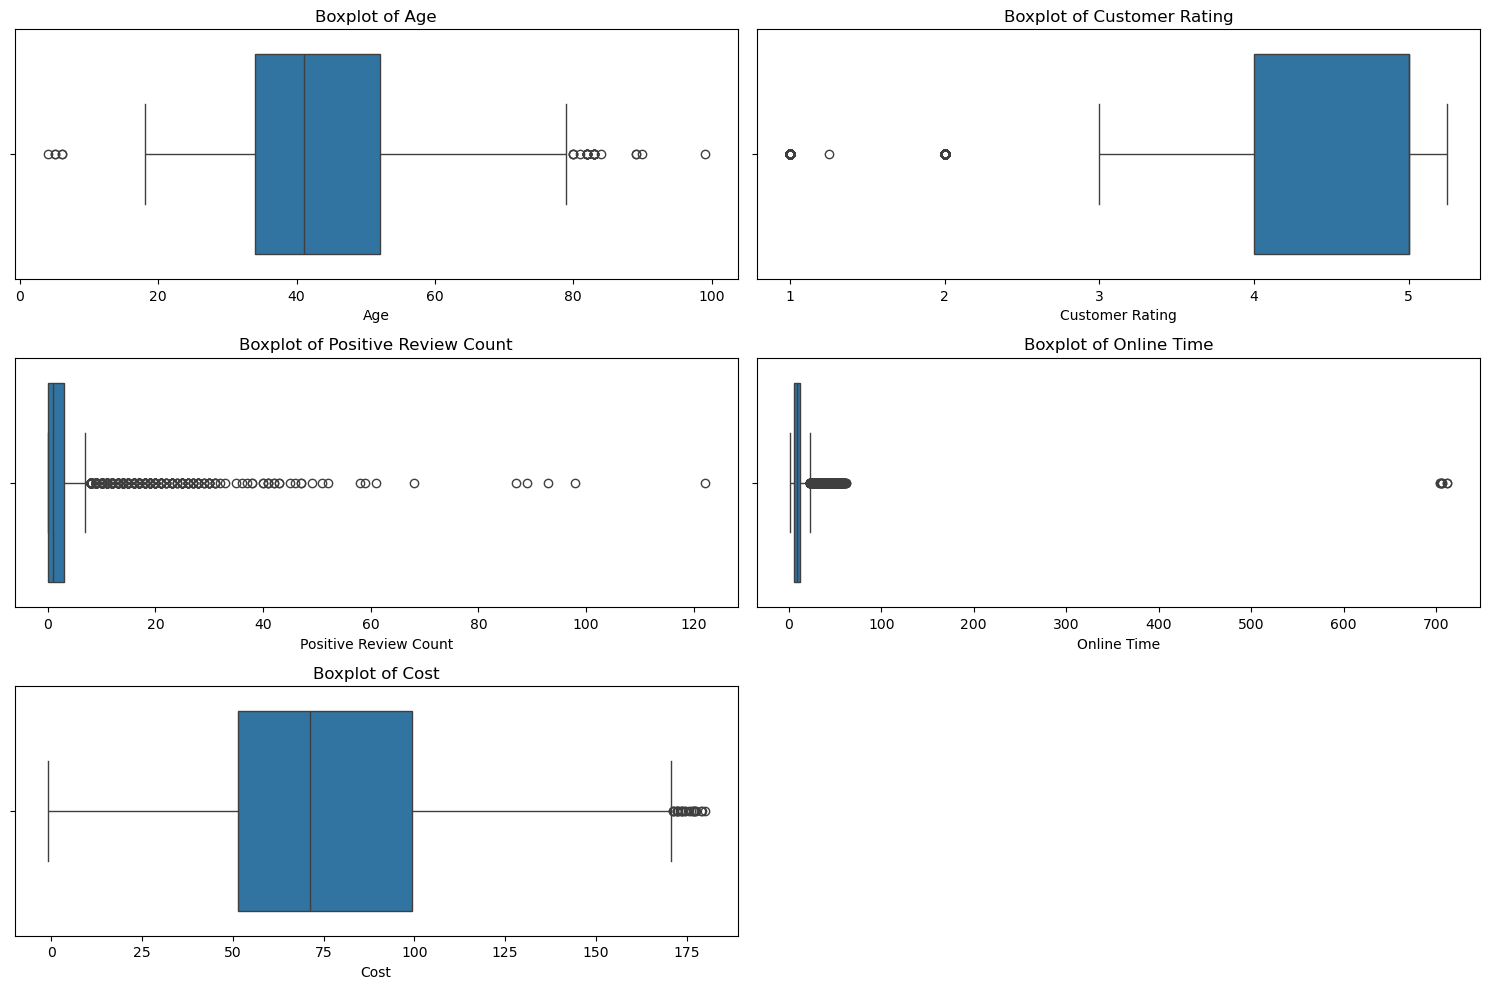

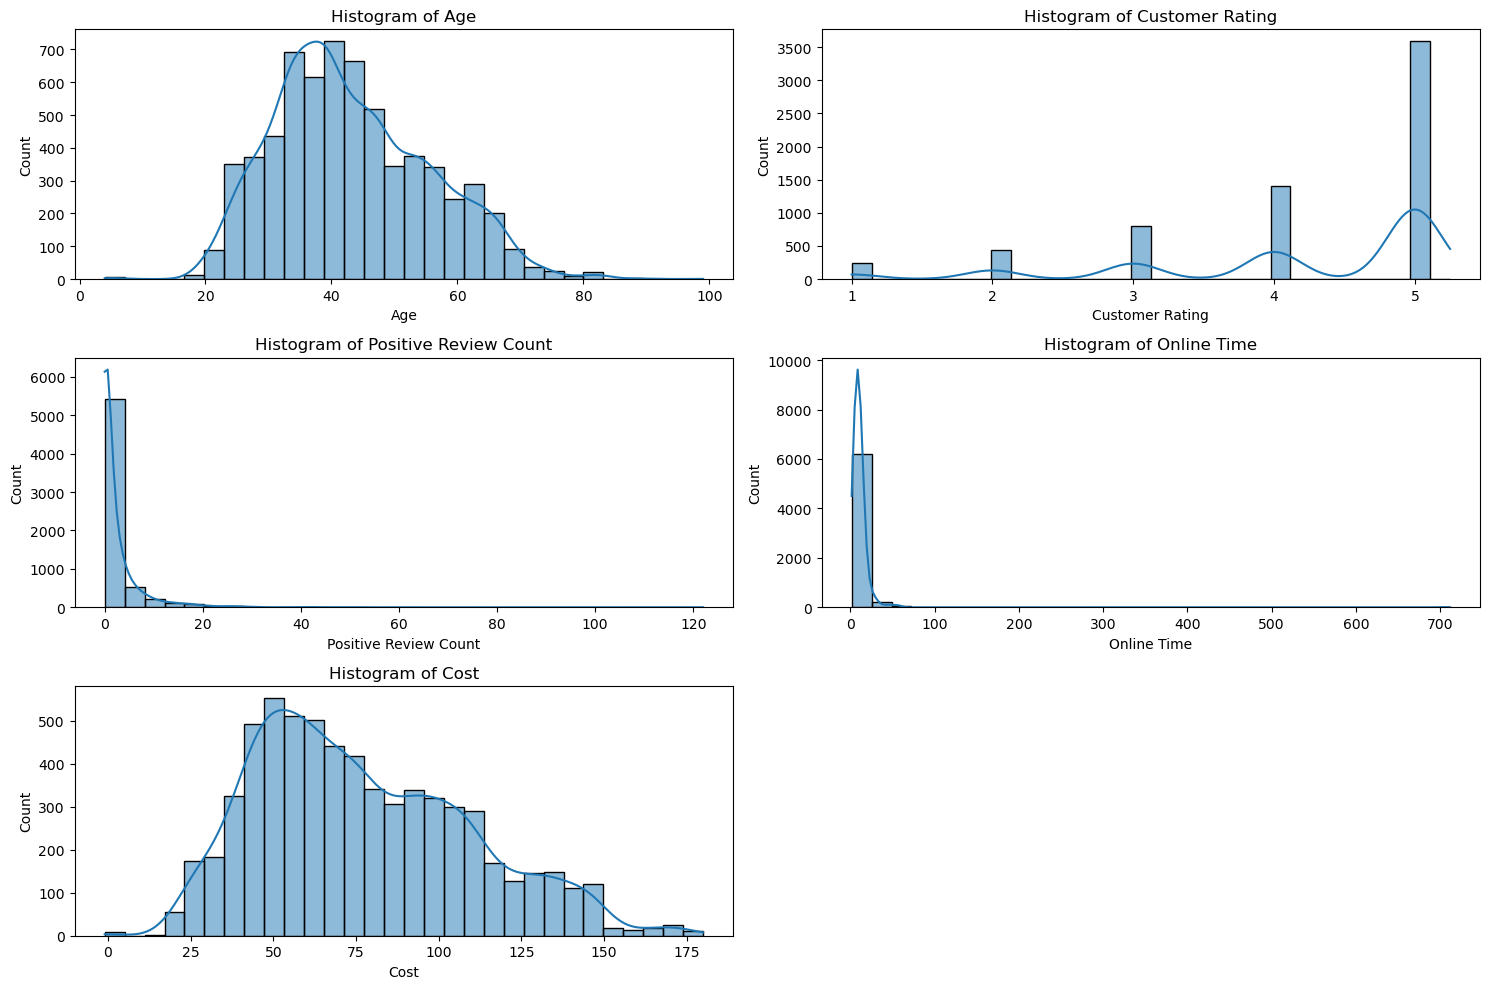

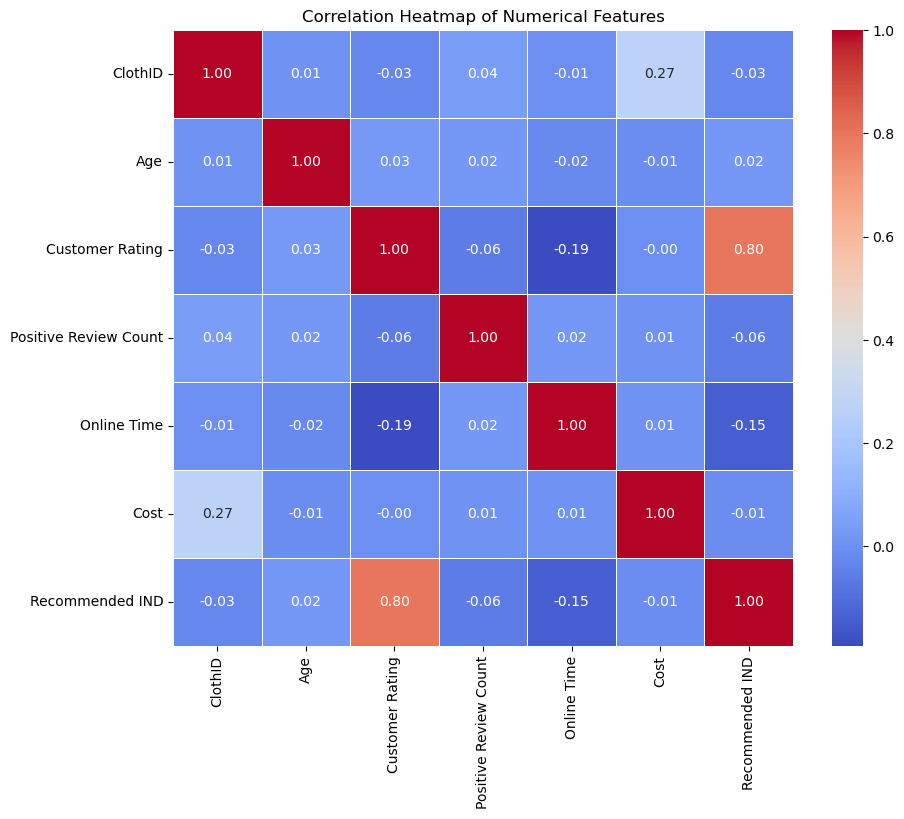

In [8]:

# Boxplots
numerical_cols = ["Age", "Customer Rating", "Positive Review Count", "Online Time", "Cost"]
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols, start=1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Histograms
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols, start=1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

# Correlation Heatmap
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## 2.3 Data Issues Identified

- Typographical errors were found in 'Category' and 'Section' fields.
- Suspicious Age values (below 13 or above 80) were identified.
- Negative Cost values were detected.
- Customer Ratings outside the standard 1–5 range were found.
- Extreme outliers in 'Online Time' and 'Positive Review Count' were detected.


In [9]:

# Find typo categories
valid_categories = [
    "Blouses", "Dresses", "Fine gauge", "Intimates", "Jackets", "Jeans",
    "Knits", "Layering", "Legwear", "Lounge", "Outerwear", "Pants",
    "Shorts", "Skirts", "Sleep", "Swim", "Trend"
]
print("\nTypo Categories:")
typo_categories = [cat for cat in df['Category'].dropna().unique() if cat not in valid_categories]
print(typo_categories)

# Find typo sections
print("\nTypo Sections:")
print(df['Section'].unique())

# Detect outliers
z_scores_online_time = np.abs(stats.zscore(df['Online Time'].dropna()))
outlier_indices_online_time = df['Online Time'].dropna().index[z_scores_online_time > 3]

z_scores_positive_review = np.abs(stats.zscore(df['Positive Review Count'].dropna()))
outlier_indices_positive_review = df['Positive Review Count'].dropna().index[z_scores_positive_review > 3]


Typo Categories:
['Sweaters', 'Knist', 'Skirst', 'Blouess', 'Boluses', 'eJans', 'Fine aguge']

Typo Sections:
['General' 'General Petite' 'Initmates']


## 2.4 Data Cleansing Actions

- Typographical errors were corrected (e.g., "Skirst" corrected to "Skirts").
- Unrealistic ages were removed.
- Negative Cost values were converted to positive values.
- Customer Ratings were rounded to the nearest integer within 1–5.
- Anomalous Online Time and Positive Review Count values were flagged but not corrected.

All data issues were systematically logged into the error list.


In [10]:

# Initialize Error List
error_list = []

# --- 1. Log Typographical Errors in Category
category_corrections = {
    'Knist': 'Knits',
    'Skirst': 'Skirts',
    'Blouess': 'Blouses',
    'Boluses': 'Blouses',
    'eJans': 'Jeans',
    'Fine aguge': 'Fine gauge'
}

for idx, row in df.iterrows():
    if row['Category'] in category_corrections.keys():
        error_list.append({
            "datasetNo": "dataset1",
            "indexOfdf": idx,
            "Id": row['ClothID'],
            "ColumnName": "Category",
            "Original": row['Category'],
            "Modified": category_corrections[row['Category']],
            "ErrorType": "Typographical Error",
            "Fixing": f'Corrected "{row["Category"]}" to "{category_corrections[row["Category"]]}"'
        })

# --- 2. Log Typographical Errors in Section
section_correction = {'Initmates': 'Intimates'}
for idx, row in df.iterrows():
    if row['Section'] in section_correction.keys():
        error_list.append({
            "datasetNo": "dataset1",
            "indexOfdf": idx,
            "Id": row['ClothID'],
            "ColumnName": "Section",
            "Original": row['Section'],
            "Modified": section_correction[row['Section']],
            "ErrorType": "Typographical Error",
            "Fixing": f'Corrected "{row["Section"]}" to "{section_correction[row["Section"]]}"'
        })

# --- 3. Log Dropped Ages
dropped_age_df = df[(df['Age'] < 13) | (df['Age'] > 80)]
for idx, row in dropped_age_df.iterrows():
    error_list.append({
        "datasetNo": "dataset1",
        "indexOfdf": idx,
        "Id": row['ClothID'],
        "ColumnName": "Age",
        "Original": row['Age'],
        "Modified": "Deleted",
        "ErrorType": "Suspicious Age",
        "Fixing": "Deleted record with unrealistic Age (<13 or >80)"
    })

# --- 4. Log Negative Cost
for idx, row in df.iterrows():
    if row['Cost'] < 0:
        corrected_cost = abs(row['Cost'])
        error_list.append({
            "datasetNo": "dataset1",
            "indexOfdf": idx,
            "Id": row['ClothID'],
            "ColumnName": "Cost",
            "Original": row['Cost'],
            "Modified": corrected_cost,
            "ErrorType": "Negative Cost Fix",
            "Fixing": "Converted negative Cost to positive using absolute value"
        })

# --- 5. Log Customer Rating Rounding
for idx, row in df.iterrows():
    if row['Customer Rating'] not in [1,2,3,4,5]:
        corrected_rating = round(row['Customer Rating'])
        error_list.append({
            "datasetNo": "dataset1",
            "indexOfdf": idx,
            "Id": row['ClothID'],
            "ColumnName": "Customer Rating",
            "Original": row['Customer Rating'],
            "Modified": corrected_rating,
            "ErrorType": "Rating Correction",
            "Fixing": f'Rounded Customer Rating from {row["Customer Rating"]} to {corrected_rating}'
        })

# --- 6. Log Outlier Flags
for idx in outlier_indices_online_time:
    error_list.append({
        "datasetNo": "dataset1",
        "indexOfdf": idx,
        "Id": df.at[idx, "ClothID"],
        "ColumnName": "Online Time",
        "Original": df.at[idx, "Online Time"],
        "Modified": df.at[idx, "Online Time"],
        "ErrorType": "Anomaly flagged",
        "Fixing": "Value flagged as extreme Online Time; no correction applied"
    })

for idx in outlier_indices_positive_review:
    error_list.append({
        "datasetNo": "dataset1",
        "indexOfdf": idx,
        "Id": df.at[idx, "ClothID"],
        "ColumnName": "Positive Review Count",
        "Original": df.at[idx, "Positive Review Count"],
        "Modified": df.at[idx, "Positive Review Count"],
        "ErrorType": "Anomaly flagged",
        "Fixing": "Value flagged as extreme Positive Review Count; no correction applied"
    })

## 2.5 Apply fixes systematically:
 - Correct typographical errors
 - Drop unrealistic ages
 - Fix negative Cost values
 - Round Customer Ratings
- Remove duplicates


In [11]:


# Correct Typos
df['Category'] = df['Category'].replace(category_corrections)
df['Section'] = df['Section'].replace(section_correction)

# Drop unrealistic Ages
df = df[(df['Age'] >= 13) & (df['Age'] <= 80)]
df = df.reset_index(drop=True)

# Fix Cost
df['Cost'] = df['Cost'].abs()

# Round Customer Ratings
df['Customer Rating'] = df['Customer Rating'].round()

# Drop Duplicates
df = df.drop_duplicates()
df = df.reset_index(drop=True)



## 2.6 SAVE OUTPUTS


In [12]:
# Save cleaned dataset
df.to_csv("S3859590_dataset1_solution.csv", index=False)

# Save error list
errorlist_df = pd.DataFrame(error_list)
errorlist_df.to_csv("S3859590_errorlist.csv", index=False)

print("Cleaned dataset and error list saved successfully.")

Cleaned dataset and error list saved successfully.


......

## Summary
Give a short summary and anything you would like to talk about the assessment here.
### 🧹 Task 2: Auditing and Cleansing Summary

In this task, the parsed XML dataset was inspected and cleansed systematically. 

- Spelling mistakes in the "Category" column were detected and corrected using regex patterns.
- Numerical constraint violations were corrected:
  - Customer ratings above 5rounded off at 5.
  - Negative cost values were replacemodith NaN.
  - Unrealistremoved
  - ith NaN.
- Anomalies were detected in numerical columns using Z-score analysis and boxplots.
- All fixes and detected anomalies were logged in the `S3859590_errorlist.csv` file for auditing and traceability.

The cleaned dataset was saved as `S3859590_dataset1_solution.csv`.
